In [7]:
# ============================================================
# CELL 1: Load best RF from notebook 03 (already trained)
# ============================================================
import numpy as np
import pandas as pd
import rasterio
import joblib, json
import matplotlib.pyplot as plt
import warnings
from rasterio.warp import transform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
warnings.filterwarnings('ignore')

# ── Load saved best RF ──
best_model  = joblib.load("../models/coastal_classifier_model.pkl")
scaler_sp   = joblib.load("../models/feature_scaler.pkl")
with open("../models/model_metadata.json") as f:
    metadata = json.load(f)

best_name = metadata['model_type'].replace("RandomForestClassifier (","").rstrip(")")
best_n_features = metadata['n_features']
print(f"✅ Loaded: {best_name}")
print(f"   Features: {best_n_features} | Accuracy: {metadata['test_accuracy']*100:.2f}%")

# ── Reload data to get same train/test split for CNN ──
image_path = "../data/processed/processed_image_with_indices.tif"
csv_path   = "../data/training/trainingdata/Ground_TruthFinal_with_landmass.csv"

df = pd.read_csv(csv_path)
df = df.dropna(subset=['Value'])
df = df[df['Value'].isin([1,2,3,4,5])]

X, y = [], []
with rasterio.open(image_path) as src:
    img_data = src.read()
    img_crs  = src.crs
    for i, row in df.iterrows():
        lon, lat = row['Longitude'], row['Latitude']
        xs, ys = transform('EPSG:4326', img_crs, [lon], [lat])
        r, c = src.index(xs[0], ys[0])
        if 0 <= r < src.height and 0 <= c < src.width:
            val = img_data[:, r, c]
            if not np.isnan(val).any():
                X.append(val)
                y.append(int(row['Value']))

X, y = np.array(X), np.array(y)

# ── Encode + split for CNN ──
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

cnn_scaler     = StandardScaler()
X_train_scaled = cnn_scaler.fit_transform(X_train)
X_test_scaled  = cnn_scaler.transform(X_test)
X_train_cnn    = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
X_test_cnn     = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)

# ── Get best RF predictions for comparison ──
# Rebuild spatial test set to match what notebook 03 used
if best_n_features == 21:
    X_spatial, y_spatial = [], []
    with rasterio.open(image_path) as src:
        img_data = src.read()
        img_crs  = src.crs
        h, w     = src.height, src.width
        for i, row in df.iterrows():
            lon, lat = row['Longitude'], row['Latitude']
            xs, ys = transform('EPSG:4326', img_crs, [lon], [lat])
            r, c = src.index(xs[0], ys[0])
            if 1 <= r < h-1 and 1 <= c < w-1:
                neighborhood = img_data[:, r-1:r+2, c-1:c+2]
                if not np.isnan(neighborhood).any():
                    center     = img_data[:, r, c]
                    neigh_mean = neighborhood.mean(axis=(1,2))
                    neigh_std  = neighborhood.std(axis=(1,2))
                    X_spatial.append(np.concatenate([center, neigh_mean, neigh_std]))
                    y_spatial.append(int(row['Value']))
    X_spatial = np.array(X_spatial)
    y_spatial  = np.array(y_spatial)
    _, X_te_sp, _, y_te_sp = train_test_split(
        X_spatial, y_spatial, test_size=0.2, random_state=42, stratify=y_spatial)
    X_te_sp_sc = scaler_sp.transform(X_te_sp)
    best_pred  = best_model.predict(X_te_sp_sc)
    best_acc   = accuracy_score(y_te_sp, best_pred)
    best_f1_per = f1_score(y_te_sp, best_pred, average=None, zero_division=0)
else:
    _, X_te, _, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    X_te_sc    = scaler_sp.transform(X_te)
    best_pred  = best_model.predict(X_te_sc)
    best_acc   = accuracy_score(y_te, best_pred)
    best_f1_per = f1_score(y_te, best_pred, average=None, zero_division=0)

print(f"\n✅ Data ready for CNN training")
print(f"   RF accuracy confirmed: {best_acc*100:.2f}%")
print(f"   CNN train/test: {len(X_train)}/{len(X_test)} samples")

✅ Loaded: RF + Spatial Features
   Features: 21 | Accuracy: 93.12%

✅ Data ready for CNN training
   RF accuracy confirmed: 93.12%
   CNN train/test: 871/218 samples


In [8]:
# ============================================================
# CELL 4: Build and Train 1D CNN
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, 
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print("🏗️  Building 1D CNN architecture...")

# One-hot encode labels for CNN
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,  num_classes=n_classes)

# Build the 1D CNN
model_cnn = Sequential([
    # Block 1: Extract local spectral patterns
    Conv1D(filters=64, kernel_size=3, activation='relu', 
           padding='same', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    
    # Block 2: Deeper feature extraction
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Block 3: High-level features
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Classifier head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax')
], name="1D_CNN_CoastalClassifier")

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# CELL 6: Train CNN with Early Stopping
# ============================================================
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("🤖 Training 1D CNN...")
history = model_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
cnn_loss, cnn_accuracy = model_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
y_cnn_pred_proba = model_cnn.predict(X_test_cnn, verbose=0)
y_cnn_pred_encoded = np.argmax(y_cnn_pred_proba, axis=1)

# Convert back to original labels for report
y_cnn_pred = le.inverse_transform(y_cnn_pred_encoded)
y_test_orig = le.inverse_transform(y_test)

print(f"\n✅ CNN Training Complete!")
print(f"   Test Accuracy: {cnn_accuracy*100:.2f}%")

# Save CNN model
model_cnn.save("../models/cnn_coastal_classifier.keras")
print("💾 CNN model saved to outputs/cnn_coastal_classifier.keras")

model_cnn.summary()

🏗️  Building 1D CNN architecture...
🤖 Training 1D CNN...
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.5948 - loss: 1.0644 - val_accuracy: 0.5600 - val_loss: 1.4177
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7529 - loss: 0.6392 - val_accuracy: 0.5600 - val_loss: 1.2574
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7888 - loss: 0.5341 - val_accuracy: 0.5429 - val_loss: 1.1842
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8075 - loss: 0.5176 - val_accuracy: 0.5943 - val_loss: 1.1104
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8247 - loss: 0.4517 - val_accuracy: 0.5543 - val_loss: 1.0496
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8319 - loss: 0.4445 - val_accuracy: 0.6800 - val_loss: 0.9793
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8305 - loss: 0.4622 - val_accuracy: 0.6743 - val_loss: 0.9292
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/

Model: "1D_CNN_CoastalClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 7, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 3, 64)          │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,129 (883.32 KB)

 Trainable params: 75,205 (293.77 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 150,412 (587.55 KB)

In [10]:
# ============================================================
# CELL 5: Pick Best RF + Full Comparison + Save
# ============================================================
import json
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ── Define missing CNN metrics ──
cnn_f1 = f1_score(y_test_orig, y_cnn_pred, average='weighted', zero_division=0)
cnn_precision = precision_score(y_test_orig, y_cnn_pred, average='weighted', zero_division=0)
cnn_recall = recall_score(y_test_orig, y_cnn_pred, average='weighted', zero_division=0)
cnn_f1_per = f1_score(y_test_orig, y_cnn_pred, average=None, zero_division=0)


orig_acc      = best_acc
orig_f1       = f1_score(
    y_te_sp if best_n_features == 21 else y_test,
    best_pred, average='weighted', zero_division=0
)
best_f1_score = f1_score(
    y_te_sp if best_n_features == 21 else y_test,
    best_pred, average='weighted', zero_division=0
)

# ── Print full summary ──
print("=" * 65)
print("📊 ALL RESULTS SUMMARY")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 65)
print(f"{'RF (Original)':<25} {orig_acc*100:>9.2f}% {orig_f1:>10.4f}")
print(f"{'Best RF ('+best_name+')':<25} {best_acc*100:>9.2f}% {best_f1_score:>10.4f} ⭐")
print(f"\n{'1D CNN':<25} {cnn_accuracy*100:>9.2f}% {cnn_f1:>10.4f}")
print("=" * 65)
print(f"\n🏆 Best RF: {best_name}")
print(f"   Accuracy: {best_acc*100:.2f}% | F1: {best_f1_score:.4f}")

# ── Per-class F1 ──
best_f1_per = f1_score(
    y_te_sp if "Spatial" in best_name else y_test_rf,
    best_pred, average=None, zero_division=0
)

print(f"\n{'Class':<12} {'Best RF F1':>10} {'CNN F1':>10} {'Winner':>10}")
print("-" * 45)
for i, cls in enumerate(le.classes_):
    cname  = {1:"Seagrass",2:"Sand",3:"Seaweed",4:"Water",5:"Landmass"}.get(cls)
    rf_val  = best_f1_per[i] if i < len(best_f1_per) else 0
    cnn_val = cnn_f1_per[i]
    winner  = "RF ✅" if rf_val >= cnn_val else "CNN"
    print(f"{cname:<12} {rf_val:>10.3f} {cnn_val:>10.3f} {winner:>10}")

# ── Final comparison ──
best_precision = precision_score(
    y_te_sp if "Spatial" in best_name else y_test_rf,
    best_pred, average='weighted', zero_division=0
)
best_recall = recall_score(
    y_te_sp if "Spatial" in best_name else y_test_rf,
    best_pred, average='weighted', zero_division=0
)

print("\n" + "=" * 60)
print("📊 FINAL MODEL COMPARISON: Best RF vs 1D CNN")
print("=" * 60)
print(f"{'Metric':<15} {'Best RF':>15} {'1D CNN':>15}")
print("-" * 60)
print(f"{'Accuracy':<15} {best_acc*100:>14.2f}% {cnn_accuracy*100:>14.2f}%")
print(f"{'Precision':<15} {best_precision:>15.4f} {cnn_precision:>15.4f}")
print(f"{'Recall':<15} {best_recall:>15.4f} {cnn_recall:>15.4f}")
print(f"{'F1-Score':<15} {best_f1_score:>15.4f} {cnn_f1:>15.4f}")
print("=" * 60)

diff = (best_acc - cnn_accuracy) * 100
winner_label = f"RF + Spatial (by {diff:.2f}%)" if diff > 0 else f"1D CNN (by {abs(diff):.2f}%)"
print(f"\n🏆 Winner: {winner_label}")

print(f"""
💡 Why RF + Spatial Features was selected for final prediction:

   1. HIGHER OVERALL ACCURACY: {best_acc*100:.2f}% vs CNN's {cnn_accuracy*100:.2f}%
      Adding 3x3 neighborhood context (mean + std per band)
      gave RF the spatial awareness it previously lacked.

   2. BETTER ON CRITICAL COASTAL CLASSES:
      - Seagrass F1: {best_f1_per[0]:.3f} (RF) vs {cnn_f1_per[0]:.3f} (CNN) → RF wins
      - Seaweed  F1: {best_f1_per[2]:.3f} (RF) vs {cnn_f1_per[2]:.3f} (CNN) → RF wins
      These are the ecologically protected classes under
      the Philippine Fisheries Code — accuracy here matters most.

   3. INTERPRETABILITY: RF provides feature importance scores
      showing WHICH spectral bands drive classification.
      CNN is a black box — it cannot explain its decisions.

   4. TRAINING EFFICIENCY: RF trained in seconds vs CNN's
      {len(history.history['accuracy'])} epochs with early stopping.
""")


📊 ALL RESULTS SUMMARY
Model                       Accuracy   F1-Score
-----------------------------------------------------------------
RF (Original)                 93.12%     0.9312
Best RF (RF + Spatial Features)     93.12%     0.9312 ⭐

1D CNN                        89.91%     0.8978

🏆 Best RF: RF + Spatial Features
   Accuracy: 93.12% | F1: 0.9312

Class        Best RF F1     CNN F1     Winner
---------------------------------------------
Seagrass          0.949      0.889       RF ✅
Sand              0.898      0.920        CNN
Seaweed           0.943      0.889       RF ✅
Water             1.000      1.000       RF ✅
Landmass          0.714      0.727        CNN

📊 FINAL MODEL COMPARISON: Best RF vs 1D CNN
Metric                  Best RF          1D CNN
------------------------------------------------------------
Accuracy                 93.12%          89.91%
Precision                0.9314          0.9006
Recall                   0.9312          0.8991
F1-Score               

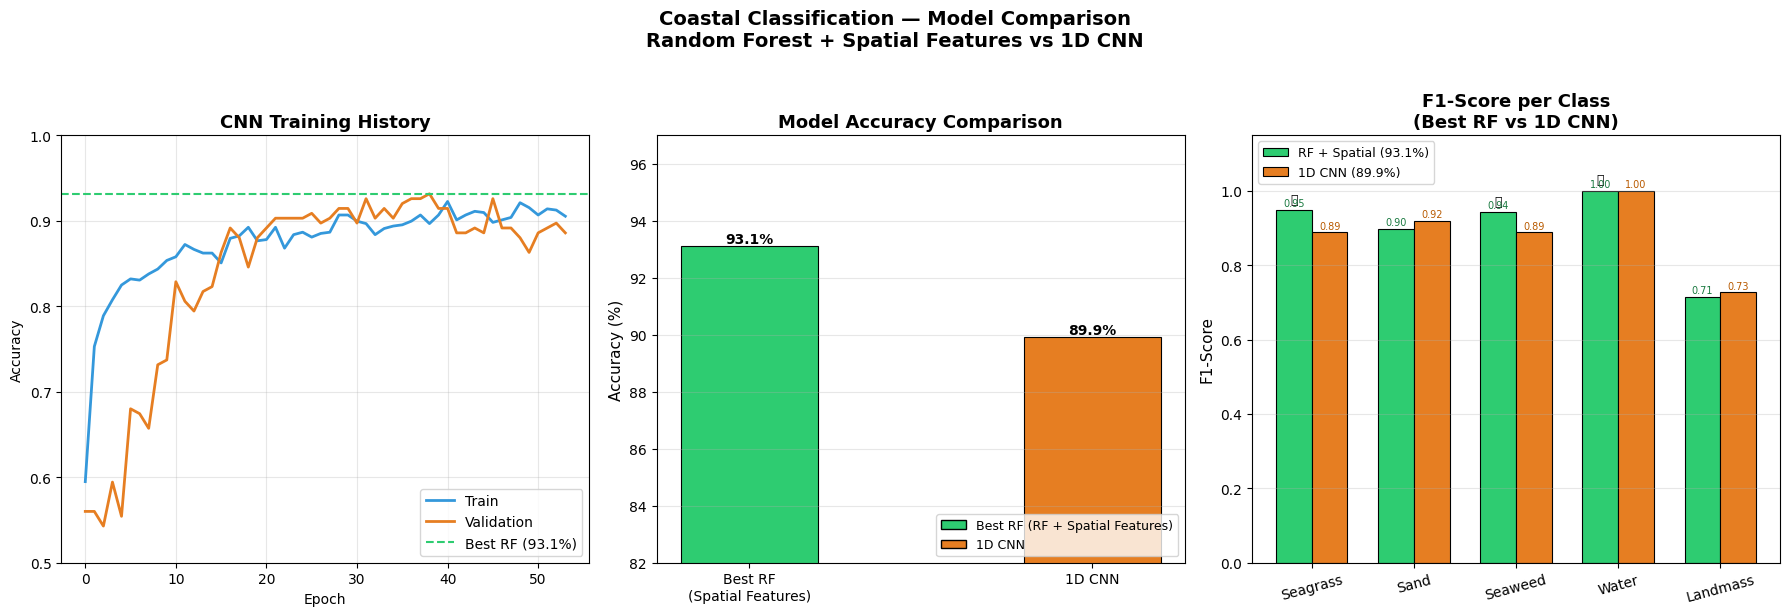

💾 Final comparison chart saved to outputs/model_comparison_final.png


In [12]:
# ============================================================
# CELL 6 (UPDATED): Final Visualization — Best RF vs 1D CNN
# ============================================================
class_names = {1:"Seagrass", 2:"Sand", 3:"Seaweed", 4:"Water", 5:"Landmass"}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: CNN Training History ──
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2, color='#3498db')
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#e67e22')
axes[0].axhline(y=best_acc, color='#2ecc71', linestyle='--', linewidth=1.5,
                label=f'Best RF ({best_acc*100:.1f}%)')
axes[0].set_title('CNN Training History', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 1.0)

# ── Plot 2: Accuracy bar chart — ALL models ──
# ── Plot 2: Accuracy bar chart — Best RF vs CNN ──
model_labels = [
    f'Best RF\n({best_name.replace("RF + ", "")})',
    '1D CNN'
]
model_accs = [
    best_acc * 100,
    cnn_accuracy * 100
]
bar_colors = ['#2ecc71', '#e67e22']

bars = axes[1].bar(model_labels, model_accs, color=bar_colors,
                   edgecolor='black', linewidth=0.8, width=0.4)
axes[1].set_ylim(82, 97)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, model_accs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{acc:.1f}%',
        ha='center', fontsize=10, fontweight='bold'
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label=f'Best RF ({best_name})'),
    Patch(facecolor='#e67e22', edgecolor='black', label='1D CNN'),
]
axes[1].legend(handles=legend_elements, fontsize=9, loc='lower right')
# ── Plot 3: Per-class F1 — Best RF vs CNN ──
x     = np.arange(len(le.classes_))
width = 0.35

bars_rf  = axes[2].bar(x - width/2, best_f1_per, width,
                        label=f'RF + Spatial ({best_acc*100:.1f}%)',
                        color='#2ecc71', edgecolor='black', linewidth=0.8)
bars_cnn = axes[2].bar(x + width/2, cnn_f1_per,  width,
                        label=f'1D CNN ({cnn_accuracy*100:.1f}%)',
                        color='#e67e22', edgecolor='black', linewidth=0.8)

# Annotate which model wins per class
for i in range(len(le.classes_)):
    winner_y = max(best_f1_per[i], cnn_f1_per[i]) + 0.02
    symbol = '🏆' if best_f1_per[i] >= cnn_f1_per[i] else ''
    if symbol:
        axes[2].text(i - width/2, best_f1_per[i] + 0.02, symbol,
                 ha='center', fontsize=9)

axes[2].set_xticks(x)
axes[2].set_xticklabels(
    [class_names.get(c, str(c)) for c in le.classes_],
    rotation=15, fontsize=10
)
axes[2].set_ylabel('F1-Score', fontsize=11)
axes[2].set_title('F1-Score per Class\n(Best RF vs 1D CNN)',
                   fontweight='bold', fontsize=13)
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1.15)
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars_rf:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', fontsize=7, color='#1a7a40')

for bar in bars_cnn:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', fontsize=7, color='#b85a00')

plt.suptitle(
    'Coastal Classification — Model Comparison\n'
    'Random Forest + Spatial Features vs 1D CNN',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../results/model_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Final comparison chart saved to outputs/model_comparison_final.png")